# Similarity and Distance Measures

DS 5001 Text as Data

# Set Up

## Config

In [1]:
import configparser
config = configparser.ConfigParser()
config.read("../../../env.ini")
data_hone = config['DEFAULT']['data_home']
output_dir = config['DEFAULT']['output_dir']

In [2]:
data_prefix = 'austen-melville'
OHCO = ['book_id', 'chap_id']
bag = 'CHAPS'
colors = "YlGnBu"
tf_agg = 'sum'

## Import

In [3]:
import pandas as pd
import numpy as np

In [4]:
import plotly_express as px
import seaborn as sns; sns.set()

In [5]:
from numpy.linalg import norm
from scipy.spatial.distance import pdist

In [6]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Prepare the Data

## Import tables

In [7]:
BOW = pd.read_csv(f"{output_dir}/{data_prefix}-BOW-{bag}.csv").set_index(OHCO+['term_str'])
LIB = pd.read_csv(f'{output_dir}/{data_prefix}-LIB.csv').set_index('book_id')

In [8]:
LIB

,source_file_path,author,title,chap_regex,book_len,n_chaps
book_id,,,,,,
105,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",PERSUASION,^Chapter\s+\d+$,83624,24
121,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",NORTHANGER ABBEY,^CHAPTER\s+\d+$,77601,31
141,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",MANSFIELD PARK,^CHAPTER\s+[IVXLCM]+$,160378,48
158,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",EMMA,^\s*CHAPTER\s+[IVXLCM]+\s*$,160926,55
161,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",SENSE AND SENSIBILITY,^CHAPTER\s+\d+$,119873,50
946,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",LADY SUSAN,^\s*[IVXLCM]+\s*$,23116,41
1212,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",LOVE AND FREINDSHIP SIC,^\s*LETTER .* to .*$,33265,24
1342,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"AUSTEN, JANE",PRIDE AND PREJUDICE,^Chapter\s+\d+$,122126,61
1900,/sfs/gpfs/tardis/home/rca2t/Documents/MSDS/DS5...,"MELVILLE, HERMAN",TYPEE A ROMANCE OF THE SOUTH SEAS,^CHAPTER,108021,34


In [9]:
BOW

n        tf     tfidf
book_id chap_id term_str                       
105     1       1         2  0.000762  0.005048
                15        1  0.000381  0.003509
                16        1  0.000381  0.003890
                1760      1  0.000381  0.003890
                1784      1  0.000381  0.003890
...                      ..       ...       ...
34970   114     ye        1  0.001550  0.003696
                yes       2  0.003101  0.005159
                yet       1  0.001550  0.000840
                young     2  0.003101  0.003566
                your      1  0.001550  0.001210

[726847 rows x 3 columns]

Add label for visualizations

In [10]:
LIB['label'] = LIB.author.str.split(', ').str[0] + ': ' +  LIB.title.str[:20] + ' (' + LIB.index.astype('str') + ')'
LIB['label'] = LIB.label.str.title()

In [11]:
LIB.label

book_id
105                    Austen: Persuasion (105)
121              Austen: Northanger Abbey (121)
141                Austen: Mansfield Park (141)
158                          Austen: Emma (158)
161          Austen: Sense And Sensibilit (161)
946                    Austen: Lady Susan (946)
1212        Austen: Love And Freindship  (1212)
1342         Austen: Pride And Prejudice (1342)
1900      Melville: Typee A Romance Of T (1900)
2701      Melville: Moby Dick Or The Wha (2701)
4045      Melville: Omoo Adventures In T (4045)
8118      Melville: Redburn His First Vo (8118)
10712    Melville: White Jacket Or The  (10712)
13720    Melville: Mardi And A Voyage T (13720)
13721    Melville: Mardi And A Voyage T (13721)
15422    Melville: Israel Potter His Fi (15422)
15859        Melville: The Piazza Tales (15859)
21816    Melville: The Confidence Man H (21816)
34970    Melville: Pierre Or The Ambigu (34970)
Name: label, dtype: object

## Generate TFIDF Matrix

Even though we already computed TFIDF in our imported BOW, we recreate it here.

Note the we can reduce the formula to a one-liner.

In [12]:
get_tfidf = lambda X, agg_func='sum': (X.T / X.T.agg(agg_func)).T * (np.log2(len(X)/X.astype('bool').sum()))

In [13]:
TFIDF_CHAP = get_tfidf(BOW.n.unstack(fill_value=0), tf_agg)

In [14]:
TFIDF_CHAP

term_str           0         1   10  100  1000  10000  10000000  10440  10800  \
book_id chap_id                                                                 
105     1        0.0  0.005048  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        2        0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        3        0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        4        0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        5        0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
...              ...       ...  ...  ...   ...    ...       ...    ...    ...   
34970   110      0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        111      0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        112      0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        113      0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   
        114      0.0  0.000000  0.0  0.0   0.0    0.0       0.0    0.0    0.0   

term_str         10th  ...  zoroaster  zozo  zuma  zur    à  æneas  æniad  \
book_id chap_id        ...                                                  
105     1         0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        2         0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        3         0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        4         0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        5         0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
...               ...  ...        ...   ...   ...  ...  ...    ...    ...   
34970   110       0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        111       0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        112       0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        113       0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   
        114       0.0  ...        0.0   0.0   0.0  0.0  0.0    0.0    0.0   

term_str         æson  æsops  ł20000  
book_id chap_id                       
105     1         0.0    0.0     0.0  
        2         0.0    0.0     0.0  
        3         0.0    0.0     0.0  
        4         0.0    0.0     0.0  
        5         0.0    0.0     0.0  
...               ...    ...     ...  
34970   110       0.0    0.0     0.0  
        111       0.0    0.0     0.0  
        112       0.0    0.0     0.0  
        113       0.0    0.0     0.0  
        114       0.0    0.0     0.0  

[1185 rows x 40281 columns]

## Collapse Bags

We want to work with larger bags in this notebook, in order to better visualize our resulting clusters.

Note that this is not the same as beginning with book as the bag! We are getting **mean TFIDF** for chapters.

In [15]:
TFIDF = TFIDF_CHAP.groupby(OHCO[:1]).mean()

In [16]:
TFIDF

term_str,0,1,10,100,1000,10000,10000000,10440,10800,10th,...,zoroaster,zozo,zuma,zur,à,æneas,æniad,æson,æsops,ł20000
book_id,,,,,,,,,,,,,,,,,,,,,
105,0.000000,0.000210,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
121,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
141,0.000000,0.000000,0.000162,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000047
158,0.000000,0.000000,0.000000,0.000000,0.000000,0.000203,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
161,0.000000,0.000047,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
946,0.000000,0.000000,0.000276,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1212,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00052,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1342,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1900,0.000000,0.000000,0.000078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Create Normalized Tables

We normalize TFIDF values in various ways. 

Normalizations types are required for certain distance measures.

In [53]:
norm?

Signature:       norm(x, ord=None, axis=None, keepdims=False)
Call signature:  norm(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function norm at 0x7fc9c03959d0>
File:            ~/.conda/envs/eta/lib/python3.9/site-packages/numpy/linalg/linalg.py
Docstring:      
Matrix or vector norm.

This function is able to return one of eight different matrix norms,
or one of an infinite number of vector norms (described below), depending
on the value of the ``ord`` parameter.

Parameters
----------
x : array_like
    Input array.  If `axis` is None, `x` must be 1-D or 2-D, unless `ord`
    is None. If both `axis` and `ord` are None, the 2-norm of
    ``x.ravel`` will be returned.
ord : {non-zero int, inf, -inf, 'fro', 'nuc'}, optional
    Order of the norm (see table under ``Notes``). inf means numpy's
    `inf` object. The default is None.
axis : {None, int, 2-tuple of ints}, optional.
    If `axis` is an integer, it specifies the axis of `x` along which to
    c

In [108]:
L0 = TFIDF.astype('bool').astype('int')    # Binary (Pseudo L)
L1 = TFIDF.apply(lambda x: x / x.sum(), 1) # Probabilistic
L2 = TFIDF.apply(lambda x: x / norm(x), 1) # Pythagorean, AKA Euclidean

## Visualize 

Pause and explore results.

We get a visual sense of what vector distance is.

In [84]:
sample_terms = "war peace love joy heart mind home ship whale england america island father sister man woman".split()

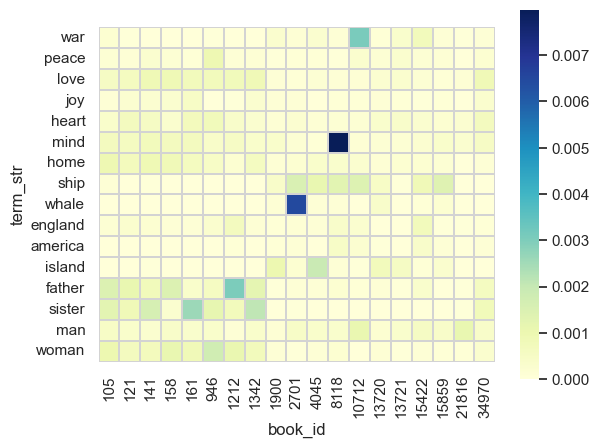

In [85]:
sns.heatmap(L1[sample_terms].T, cmap=colors, linewidth=.01, linecolor="lightgray", square=True);

## Create Doc Pair Table

Create a table to store our results.

Note that `pist()` is a "distance matrix computation from a collection of raw observation vectors stored in a rectangular array".

Note: We might also use [sklearn.metrics.DistanceMetric](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html#sklearn.metrics.DistanceMetric) and [sklearn.metrics.pairwise.cosine_distances](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_distances.html#sklearn.metrics.pairwise.cosine_distances)

In [86]:
# Create dataframe with cartesian product of books by books
PAIRS = pd.DataFrame(index=pd.MultiIndex.from_product([LIB.index.tolist(), LIB.index.tolist()])).reset_index()

In [87]:
PAIRS

,level_0,level_1
0,105,105
1,105,121
2,105,141
3,105,158
4,105,161
...,...,...
356,34970,13721
357,34970,15422
358,34970,15859
359,34970,21816


In [88]:
# Keep only unique pairs of different books
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0','level_1'])

In [89]:
PAIRS

Empty DataFrame
Columns: []
Index: [(105, 121), (105, 141), (105, 158), (105, 161), (105, 946), (105, 1212), (105, 1342), (105, 1900), (105, 2701), (105, 4045), (105, 8118), (105, 10712), (105, 13720), (105, 13721), (105, 15422), (105, 15859), (105, 21816), (105, 34970), (121, 141), (121, 158), (121, 161), (121, 946), (121, 1212), (121, 1342), (121, 1900), (121, 2701), (121, 4045), (121, 8118), (121, 10712), (121, 13720), (121, 13721), (121, 15422), (121, 15859), (121, 21816), (121, 34970), (141, 158), (141, 161), (141, 946), (141, 1212), (141, 1342), (141, 1900), (141, 2701), (141, 4045), (141, 8118), (141, 10712), (141, 13720), (141, 13721), (141, 15422), (141, 15859), (141, 21816), (141, 34970), (158, 161), (158, 946), (158, 1212), (158, 1342), (158, 1900), (158, 2701), (158, 4045), (158, 8118), (158, 10712), (158, 13720), (158, 13721), (158, 15422), (158, 15859), (158, 21816), (158, 34970), (161, 946), (161, 1212), (161, 1342), (161, 1900), (161, 2701), (161, 4045), (161, 8118), (161, 10712), (161, 13720), (161, 13721), (161, 15422), (161, 15859), (161, 21816), (161, 34970), (946, 1212), (946, 1342), (946, 1900), (946, 2701), (946, 4045), (946, 8118), (946, 10712), (946, 13720), (946, 13721), (946, 15422), (946, 15859), (946, 21816), (946, 34970), (1212, 1342), (1212, 1900), (1212, 2701), (1212, 4045), (1212, 8118), (1212, 10712), (1212, 13720), ...]

[171 rows x 0 columns]

In [90]:
# Name index cols
PAIRS.index.names = ['doc_a', 'doc_b']

In [91]:
PAIRS.shape

(171, 0)

In [92]:
PAIRS.head()

Empty DataFrame
Columns: []
Index: [(105, 121), (105, 141), (105, 158), (105, 161), (105, 946)]

## Compute Distances

Now we use `pdist()` to compute a bunch of pairwise distances.

Note that the pairs generate by `pdist()` will match those we created in `PAIRS`.

We associate measure types with the right norms.

In [93]:
pdist(TFIDF, 'cosine')

array([0.65304541, 0.63235807, 0.65328819, 0.67498755, 0.75060065,
       0.73285668, 0.61369066, 0.82228407, 0.84068187, 0.78303864,
       0.92978219, 0.80554298, 0.82380947, 0.88160095, 0.87097887,
       0.86714513, 0.93000045, 0.83874341, 0.56618896, 0.58259758,
       0.61007874, 0.67952719, 0.68036116, 0.53883163, 0.78407776,
       0.81250004, 0.75653179, 0.91624988, 0.79288647, 0.78379728,
       0.84914415, 0.84558648, 0.85394909, 0.92108352, 0.79864231,
       0.56591393, 0.58532869, 0.67733003, 0.68074215, 0.55148793,
       0.79317242, 0.81664371, 0.75699125, 0.92151306, 0.7989345 ,
       0.7914146 , 0.85545329, 0.85544514, 0.85945389, 0.92630506,
       0.80467638, 0.6134842 , 0.69467749, 0.69936628, 0.53301343,
       0.80879713, 0.82861988, 0.7805295 , 0.92790934, 0.81390695,
       0.80834421, 0.86446184, 0.86784041, 0.87117289, 0.92491835,
       0.82008984, 0.70473845, 0.673063  , 0.59174822, 0.80343195,
       0.83738859, 0.78622984, 0.9251645 , 0.8221084 , 0.80843

**A note on cosine:**

> Cosine distance and cosine similarity are complementary measures.\
> Cosine similarity measures how similar two vectors are, ranging from $-1$ (exactly opposite) to $1$ (exactly the same).\
> Cosine distance, on the other hand, measures how different two vectors are and is calculated as $1$ minus the Cosine Similarity.\
> Cosine distance has a domain between $0$ and $2$.

In [94]:
PAIRS['cityblock'] = pdist(TFIDF, 'cityblock')
PAIRS['euclidean'] = pdist(TFIDF, 'euclidean')
PAIRS['cosine'] = pdist(TFIDF, 'cosine') # Computes distance
PAIRS['jaccard'] = pdist(L0, 'jaccard')
PAIRS['dice'] = pdist(L0, 'dice')
PAIRS['js'] = pdist(L1, 'jensenshannon')  
# PAIRS['euclidean2'] = pdist(L2, 'euclidean') # Should be the same as cosine (colinear)

In [95]:
PAIRS.loc[105].style.background_gradient(cmap="YlGnBu", axis=0)

,cityblock,euclidean,cosine,jaccard,dice,js
doc_b,,,,,,
121,1.482975,0.059131,0.653045,0.569171,0.397791,0.501930
141,1.298470,0.057748,0.632358,0.546407,0.375901,0.466735
158,1.317204,0.060311,0.653288,0.550644,0.379923,0.475475
161,1.384517,0.062074,0.674988,0.542442,0.372158,0.483332
946,1.871948,0.074370,0.750601,0.669475,0.503166,0.575613
1212,2.085792,0.065899,0.732857,0.661977,0.494743,0.595912
1342,1.379645,0.057888,0.613691,0.544199,0.373814,0.479573
1900,2.352061,0.060611,0.822284,0.692781,0.529966,0.618501
2701,2.625822,0.061565,0.840682,0.781579,0.641468,0.649304


## Compare Distributions

In [96]:
SAMPLE = PAIRS.sample(1000) if PAIRS.shape[0] > 1000 else PAIRS

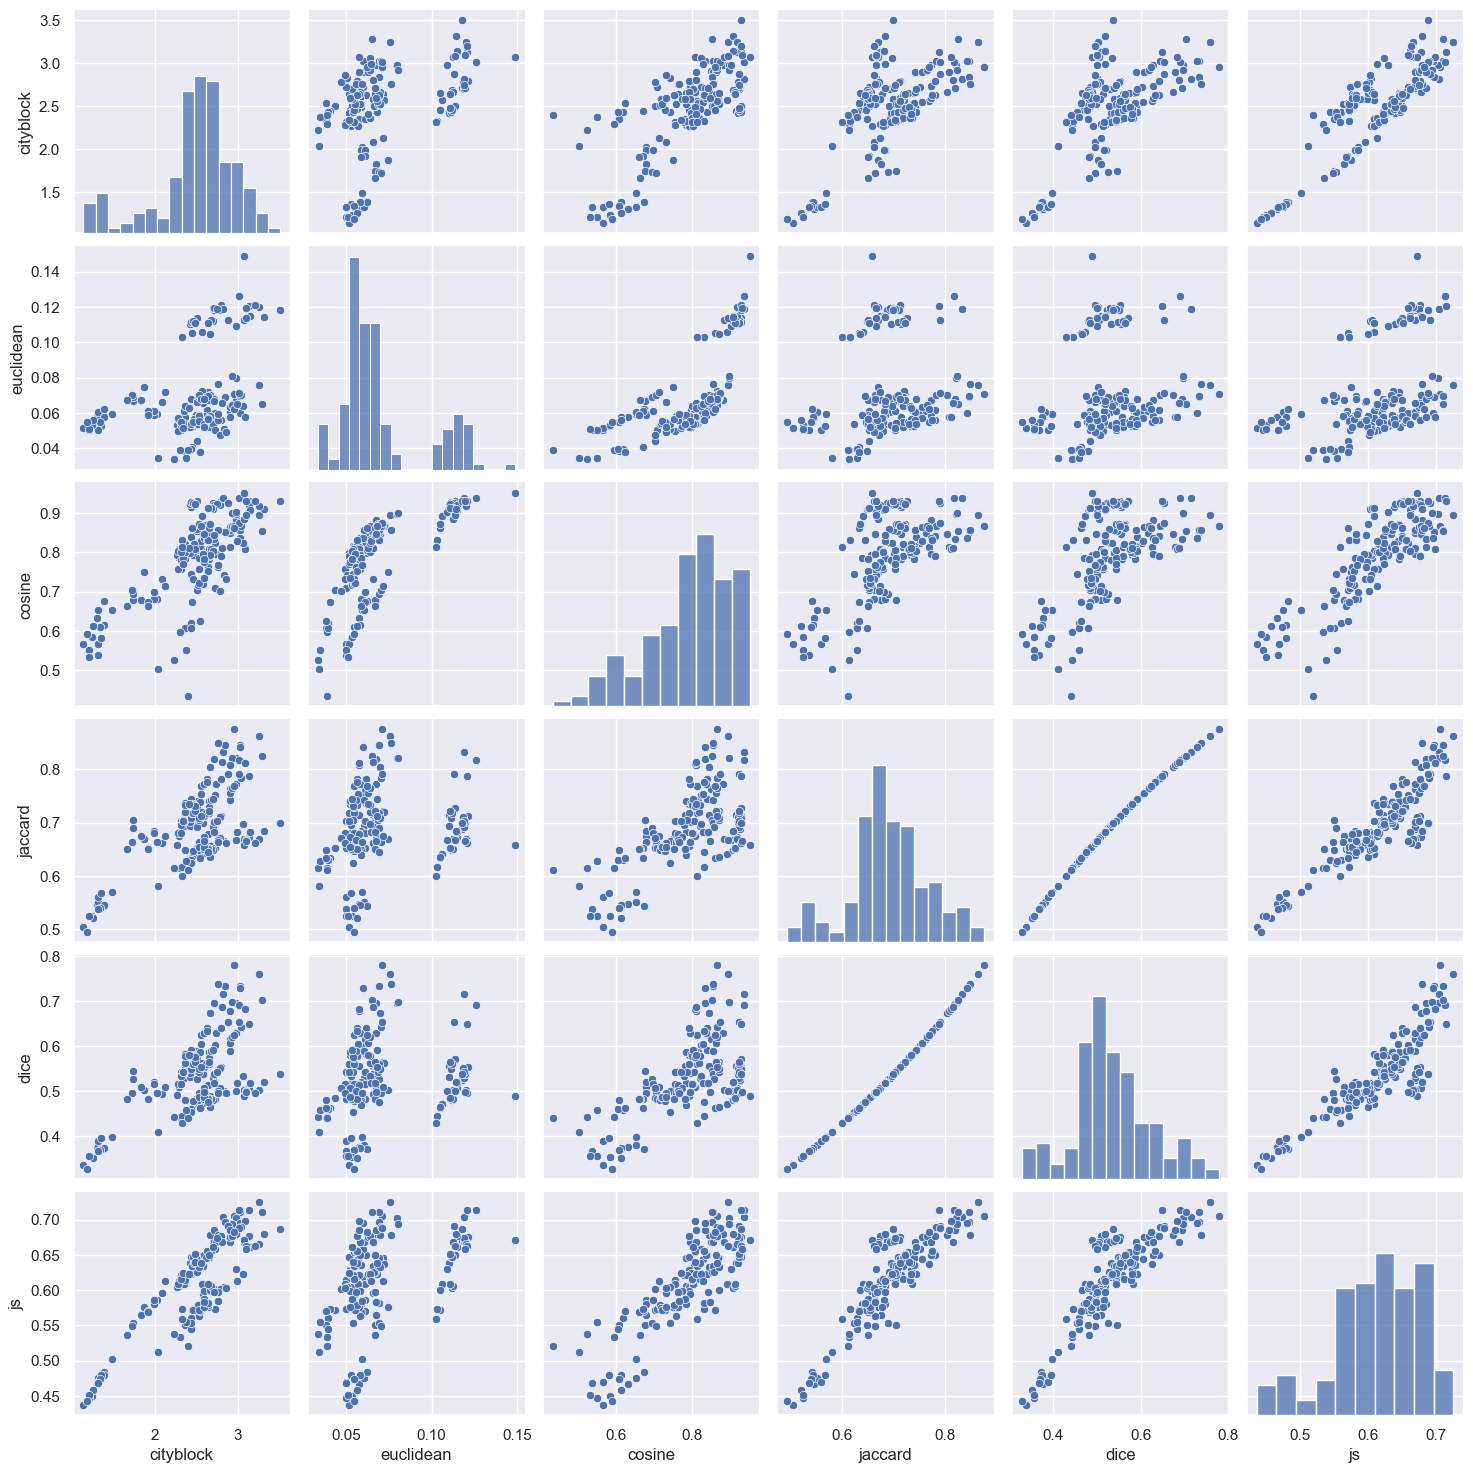

In [97]:
sns.pairplot(SAMPLE);

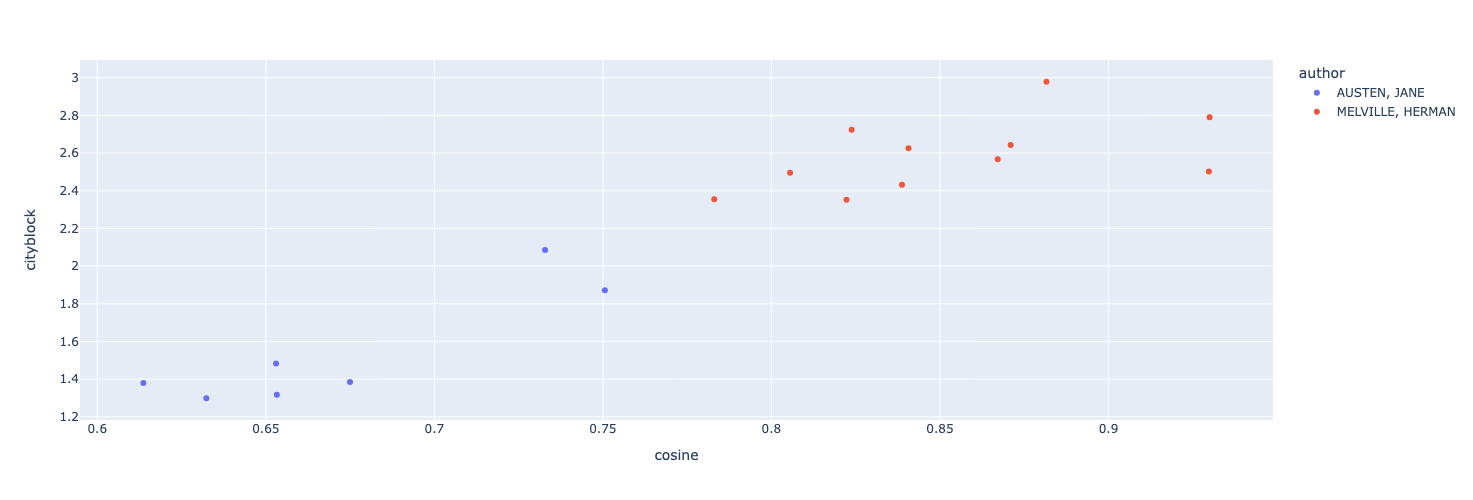

In [98]:
px.scatter(PAIRS.loc[105].join(LIB), 'cosine', 'cityblock', 
           color='author', 
           hover_name='label', 
           width=650, height=500)

In [99]:
PAIRS.sort_values('cosine').head(20).style.background_gradient(colors)

# Create Clusters

We now use our pair-wise distances between books to apply aggomerative clustering.

We visualize the clustering using a dendrogram. 

## Hiearchical

In [100]:
def hac(sims, linkage_method='complete', color_thresh=.3, figsize=(10, 10)):

    # Generate the clustering
    tree = sch.linkage(sims, method=linkage_method)
    
    # Get labels for the leaves
    labels = LIB.label.values
    
    # Create a figure 
    plt.figure()
    fig, axes = plt.subplots(figsize=figsize)
    
    # Create a dendrogram with the tree
    dendrogram = sch.dendrogram(tree, 
                                labels=labels, 
                                orientation="left", 
                                count_sort=True,
                                distance_sort=True,
                                above_threshold_color='.75',
                                color_threshold=color_thresh
                               )
    
    # Change the appearance of ticks, tick labels, and gridlines
    plt.tick_params(axis='both', which='major', labelsize=14)

<Figure size 640x480 with 0 Axes>

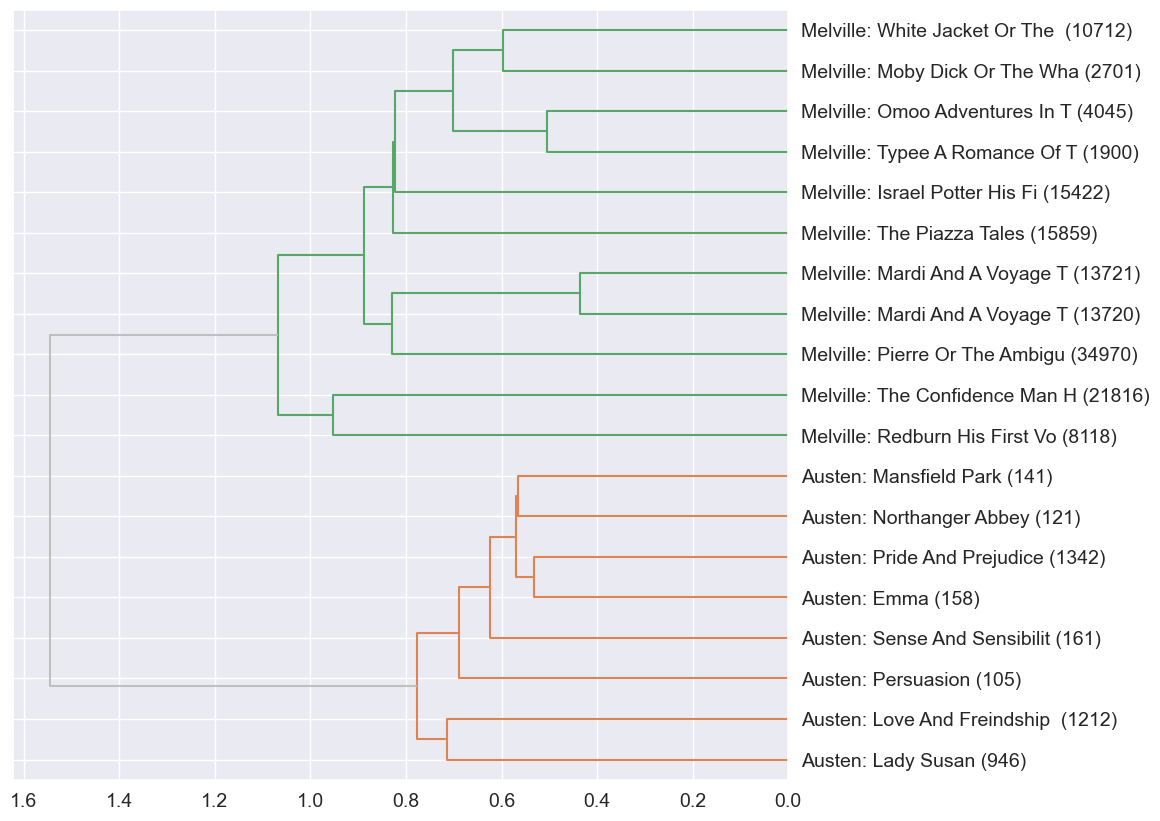

In [101]:
hac(PAIRS.cosine, linkage_method='ward', color_thresh=1.2)

<Figure size 640x480 with 0 Axes>

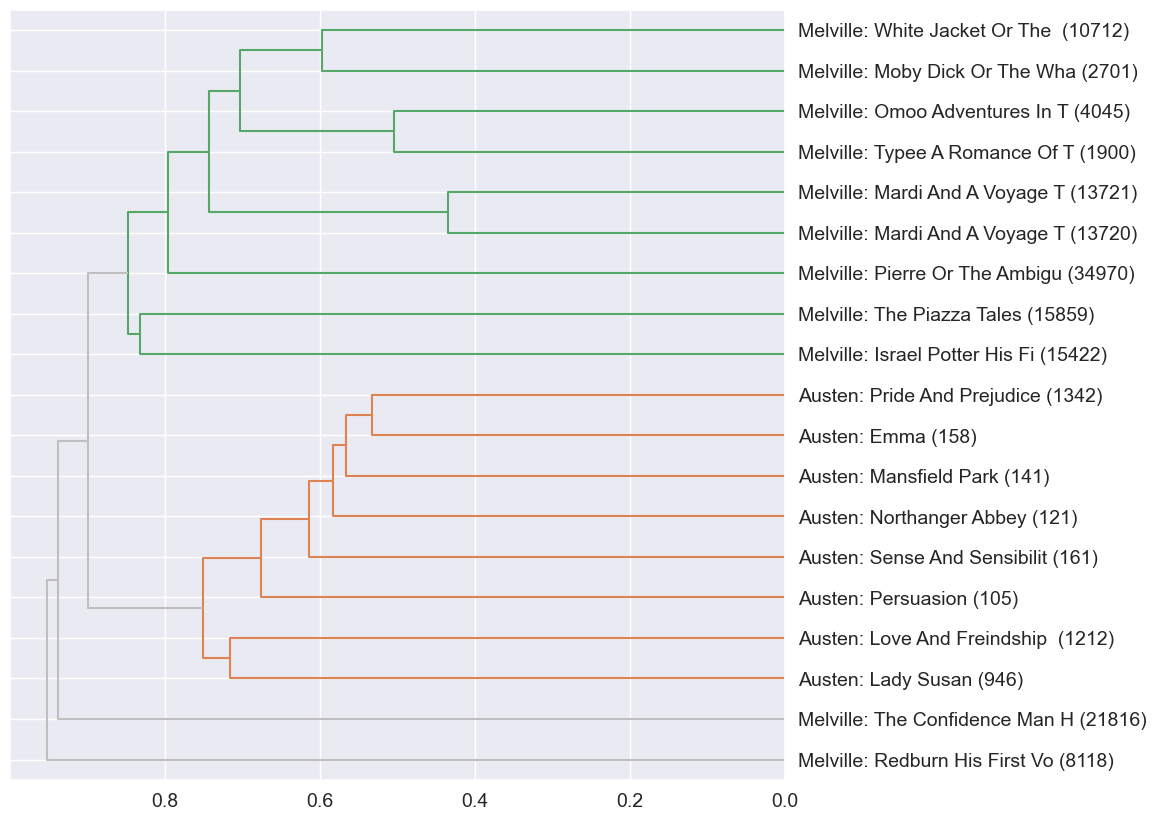

In [102]:
hac(PAIRS.cosine, linkage_method='complete', color_thresh=.85);

<Figure size 640x480 with 0 Axes>

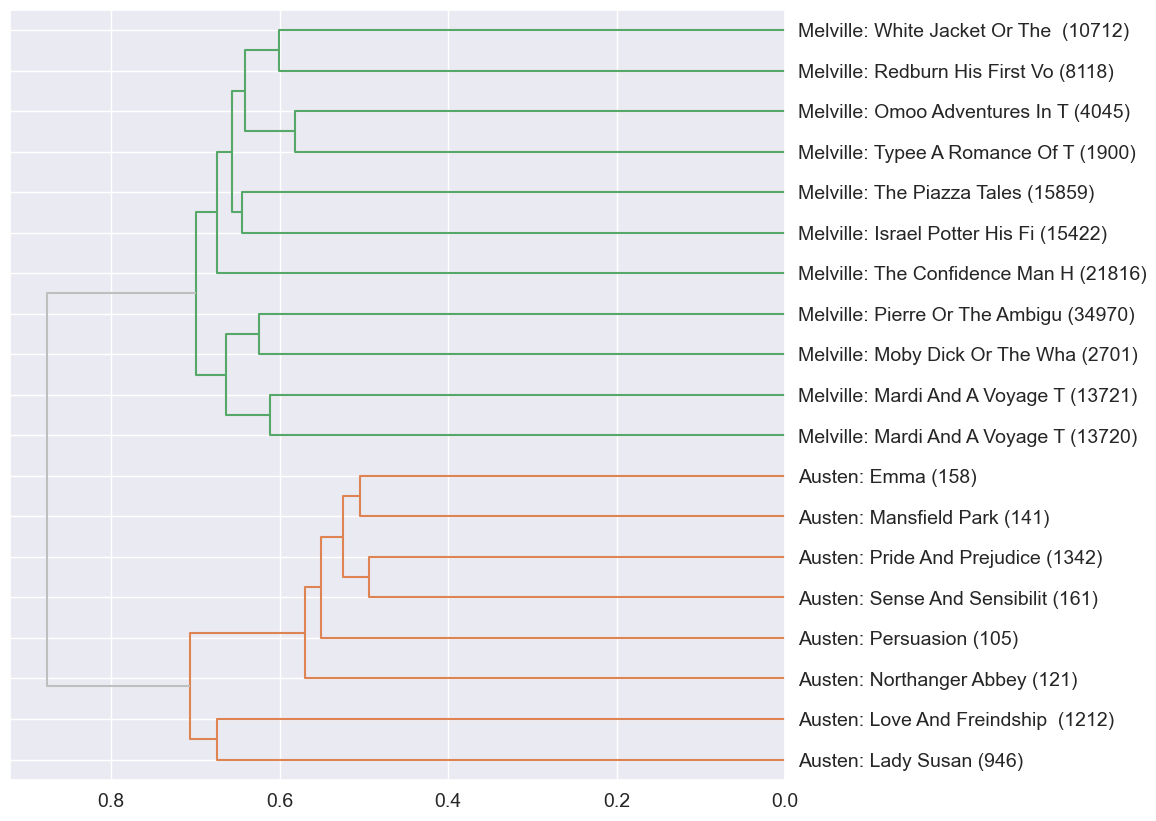

In [103]:
hac(PAIRS.jaccard, color_thresh=.8);

<Figure size 640x480 with 0 Axes>

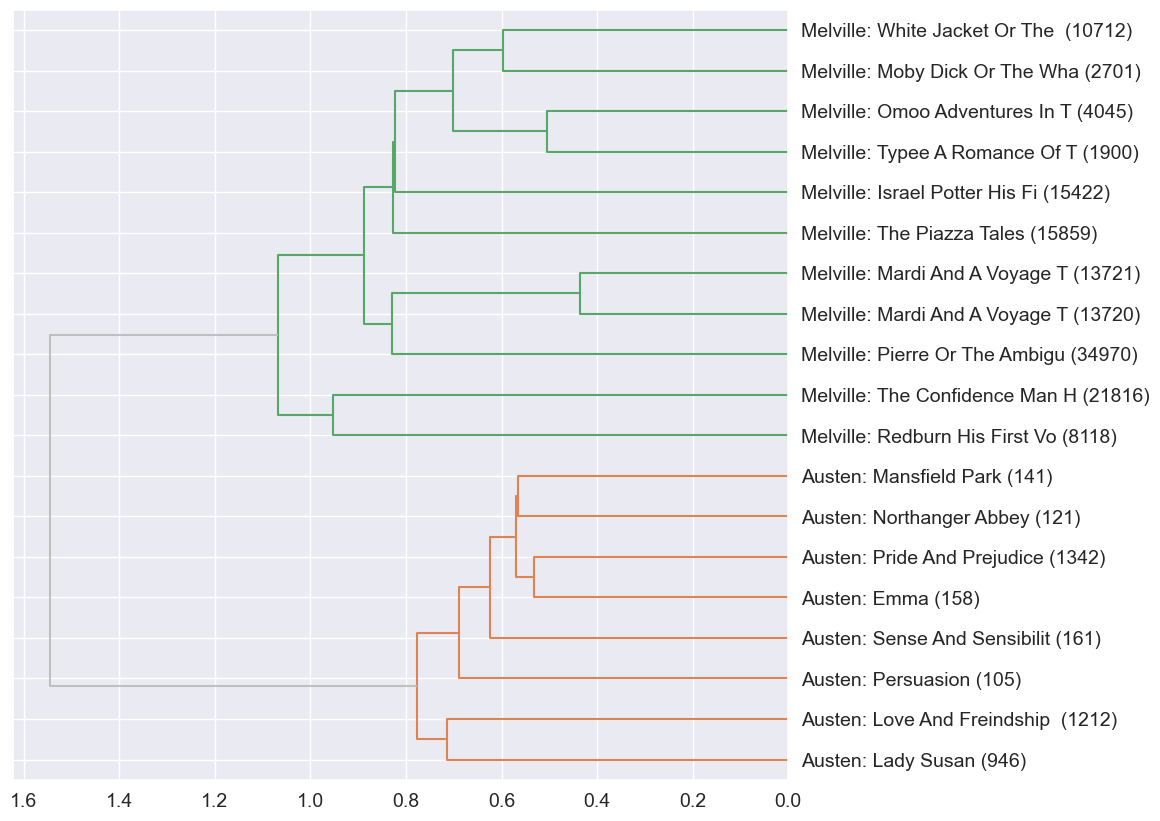

In [104]:
hac(PAIRS.cosine, linkage_method='ward', color_thresh=1.2);

<Figure size 640x480 with 0 Axes>

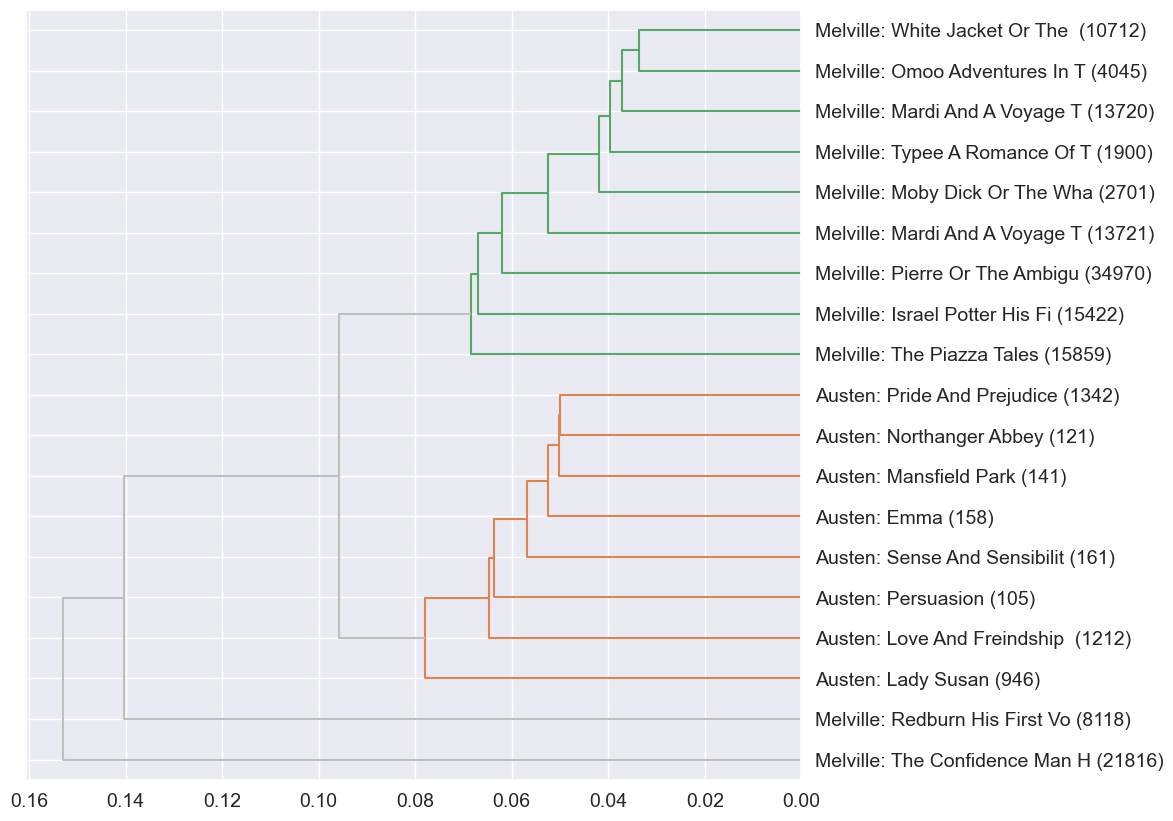

In [105]:
hac(PAIRS.euclidean, linkage_method='ward', color_thresh=.08);

<Figure size 640x480 with 0 Axes>

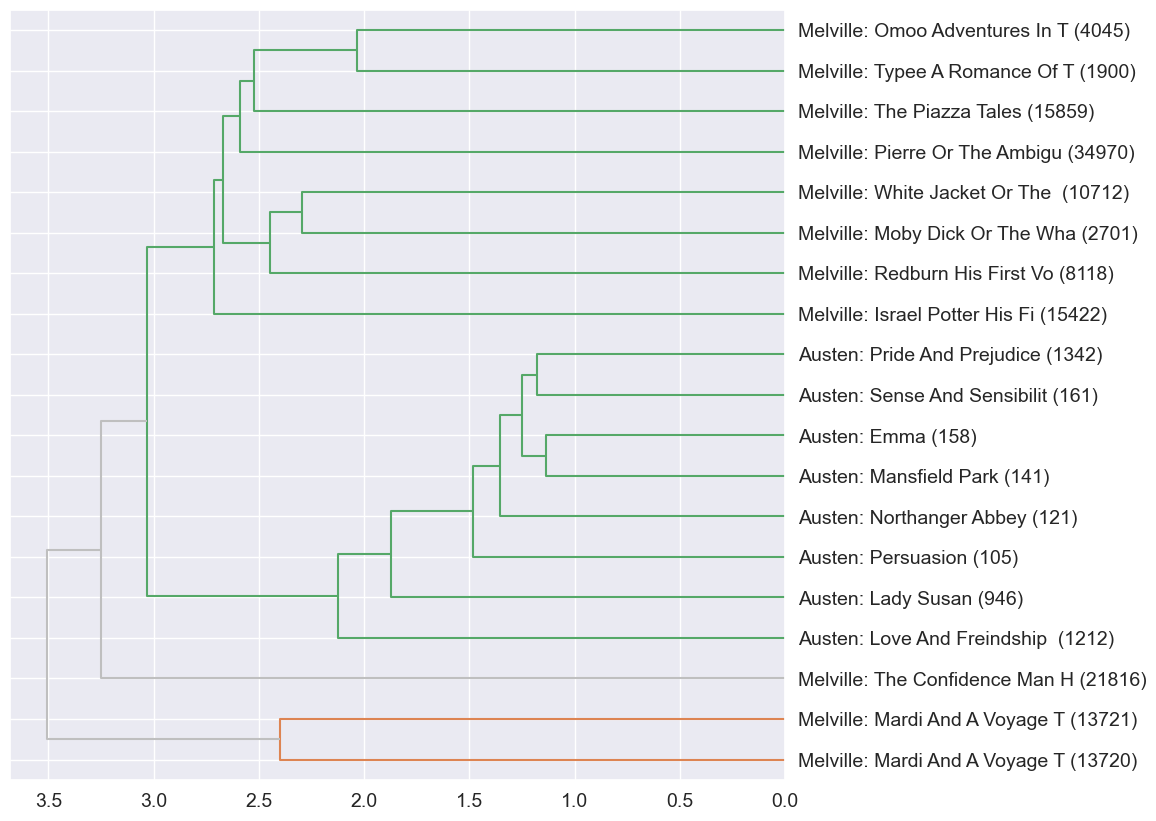

In [106]:
hac(PAIRS.cityblock, color_thresh=3.1);

<Figure size 640x480 with 0 Axes>

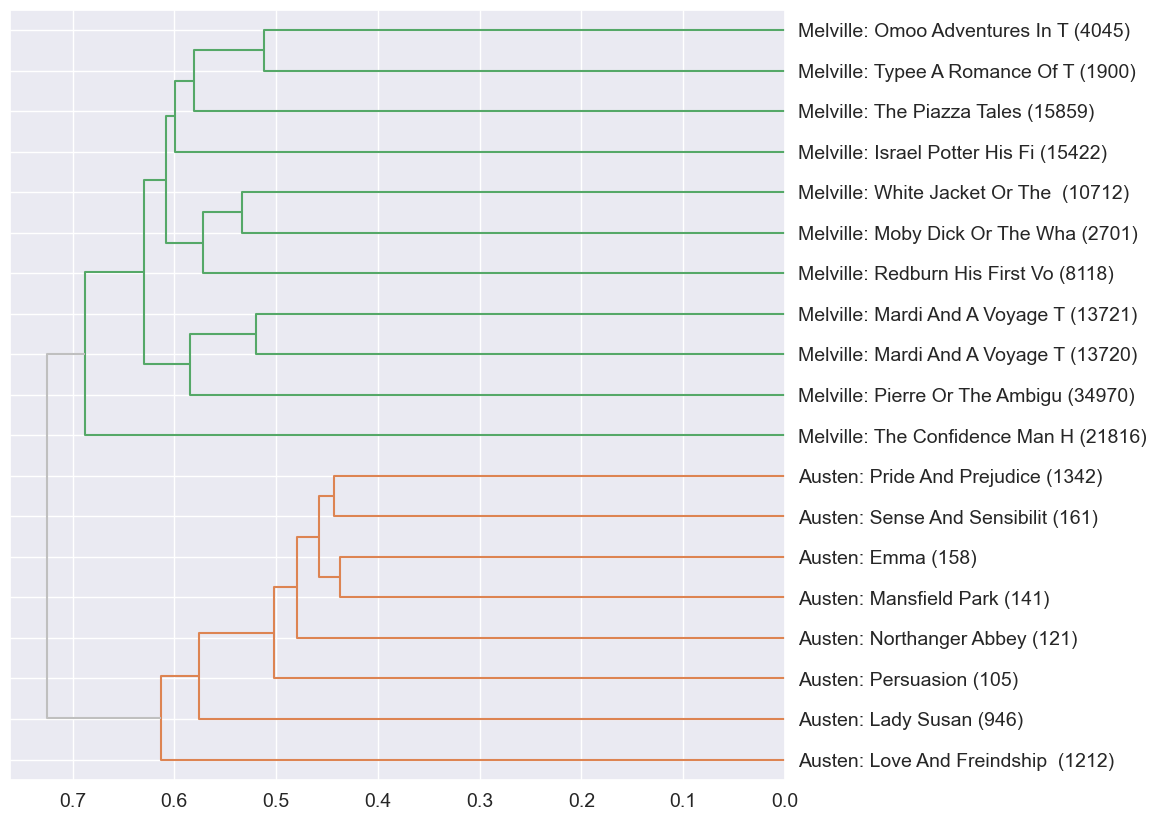

In [107]:
hac(PAIRS.js, color_thresh=.7);

## Questions

What distance measures produce the best results?

## K-Means

K-Means *only* uses Euclidean distance. Why?

* The K-Means procedure does not explicitly use pairwise distances between data points. 
* Instead, it repeatedly assigns points to the closest centroid thereby using Euclidean distance from data points to a centroid. 
* However, K-Means is *implicitly* based on pairwise Euclidean distances between data points, because the sum of squared deviations from centroid is equal to the sum of pairwise squared Euclidean distances divided by the number of points. 
* The term "centroid" is itself from Euclidean geometry. It is multivariate mean in Euclidean space. Euclidean space is about euclidean distances. Non-Euclidean distances will generally not span Euclidean space. That's why K-Means is for Euclidean distances only.

See the [Cross Validated](https://stats.stackexchange.com/questions/81481/why-does-k-means-clustering-algorithm-use-only-euclidean-distance-metric) post on this.

In [48]:
from sklearn.cluster import KMeans

In [49]:
def get_k_clusters(k=10, n_init='auto'):
    LIB[f'y_raw_{k}'] = KMeans(k, n_init=n_init).fit_predict(TFIDF)
    LIB[f'y_L0_{k}']  = KMeans(k, n_init=n_init).fit_predict(L0)
    LIB[f'y_L1_{k}']  = KMeans(k, n_init=n_init).fit_predict(L1)
    LIB[f'y_L2_{k}']  = KMeans(k, n_init=n_init).fit_predict(L2)
    y_cols = [col for col in LIB.columns if 'y_' in col and f'_{k}' in col]
    return LIB.reset_index().set_index('label')[y_cols].sort_values('label').style.background_gradient(colors)

In [50]:
get_k_clusters(2)

,y_raw_2,y_L0_2,y_L1_2,y_L2_2
label,,,,
Austen: Emma (158),1,1,0,1
Austen: Lady Susan (946),1,1,1,1
Austen: Love And Freindship (1212),1,1,1,1
Austen: Mansfield Park (141),1,1,1,1
Austen: Northanger Abbey (121),1,1,1,1
Austen: Persuasion (105),1,1,1,1
Austen: Pride And Prejudice (1342),1,1,0,1
Austen: Sense And Sensibilit (161),1,1,1,1
Melville: Israel Potter His Fi (15422),1,0,1,0


In [51]:
get_k_clusters(4)

,y_raw_4,y_L0_4,y_L1_4,y_L2_4
label,,,,
Austen: Emma (158),0,1,2,1
Austen: Lady Susan (946),3,1,2,1
Austen: Love And Freindship (1212),0,1,2,1
Austen: Mansfield Park (141),0,1,2,1
Austen: Northanger Abbey (121),0,1,2,1
Austen: Persuasion (105),0,1,2,1
Austen: Pride And Prejudice (1342),0,1,2,1
Austen: Sense And Sensibilit (161),0,1,2,1
Melville: Israel Potter His Fi (15422),2,1,2,3


# Conclusions

* Cosine similarty with Ward Linkage for HAC seems best.
* L2 normalization for K-Means seems best.
* More variance and entropy in Melville compared to Austen.

# Save Work

In [ ]:
LIB.to_csv(f"{output_dir}/{data_prefix}-LIB_LABELS.csv", index=True)
TFIDF.to_csv(f"{output_dir}/{data_prefix}-TFIDF-BOOKS.csv", index=True)